# 09 — Results and Conclusions

The consolidated scorecard: every strategy in this repo, evaluated on the
same symbol (MSFT), same out-of-sample window (2020–2023), same starting
cash, position limits, commission, and market impact.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from quantlab.backtest import affordable_shares, positions_to_trades, run_backtest, summarize
from quantlab.backtest.engine import buy_and_hold_benchmark
from quantlab.data import load_prices
from quantlab.rl import QLearner, TradingEnvironment
from quantlab.strategies import ManualRuleStrategy, MLTradingStrategy

plt.rcParams["figure.figsize"] = (11, 5)

SYMBOL = "MSFT"
TRAIN = slice("2016-01-01", "2019-12-31")
TEST = slice("2020-01-01", "2023-12-31")
START_CASH = 100_000
COMMISSION = 1.00
IMPACT = 0.001

prices = load_prices(SYMBOL, "2016-01-01", "2023-12-31")[SYMBOL]
train_prices, test_prices = prices.loc[TRAIN], prices.loc[TEST]
MAX_SHARES = affordable_shares(test_prices, START_CASH)


def backtest_positions(positions, window_prices, name):
    trades = positions_to_trades(positions, max_shares=MAX_SHARES)
    values = run_backtest(
        trades, window_prices, start_cash=START_CASH, commission=COMMISSION, impact=IMPACT
    )["value"]
    return values, summarize(values, name)

## Re-run every strategy under identical conditions

In [2]:
curves = {}
stats_rows = []

# Buy & hold benchmark
bench = buy_and_hold_benchmark(test_prices, START_CASH, MAX_SHARES, COMMISSION, IMPACT)["value"]
curves["Buy & hold"] = bench
stats_rows.append(summarize(bench, "Buy & hold"))

# Manual rule strategy (notebook 06)
manual_vals, manual_stats = backtest_positions(
    ManualRuleStrategy().positions(test_prices), test_prices, "Manual rules"
)
curves["Manual rules"] = manual_vals
stats_rows.append(manual_stats)

# ML strategy learner (notebook 07)
ml = MLTradingStrategy(n_estimators=25, leaf_size=5, lookahead=5, trade_threshold=0.01, seed=42)
ml.fit(train_prices)
ml_vals, ml_stats = backtest_positions(ml.positions(test_prices), test_prices, "ML learner")
curves["ML learner"] = ml_vals
stats_rows.append(ml_stats)

# Q-learning agent (notebook 08)
env = TradingEnvironment(n_bins=4, impact=IMPACT)
env.fit_bins(train_prices)
q = QLearner(env.num_states, env.num_actions, alpha=0.2, gamma=0.9, epsilon=0.5, epsilon_decay=0.9995, seed=42)
env.train(train_prices, q, n_episodes=150)
rl_vals, rl_stats = backtest_positions(env.positions(test_prices, q), test_prices, "Q-learner")
curves["Q-learner"] = rl_vals
stats_rows.append(rl_stats)

scorecard = pd.DataFrame(stats_rows)
scorecard.round(4)

,cumulative_return,avg_daily_return,daily_volatility,sharpe_ratio,max_drawdown,final_value
Buy & hold,1.4296,0.0011,0.0205,0.8458,-0.3715,242713.6608
Manual rules,0.3305,0.0007,0.0290,0.3844,-0.4538,133045.5495
ML learner,1.8541,0.0012,0.0190,1.0240,-0.2704,285411.7386
Q-learner,0.0610,0.0001,0.0106,0.1716,-0.3138,106102.5980


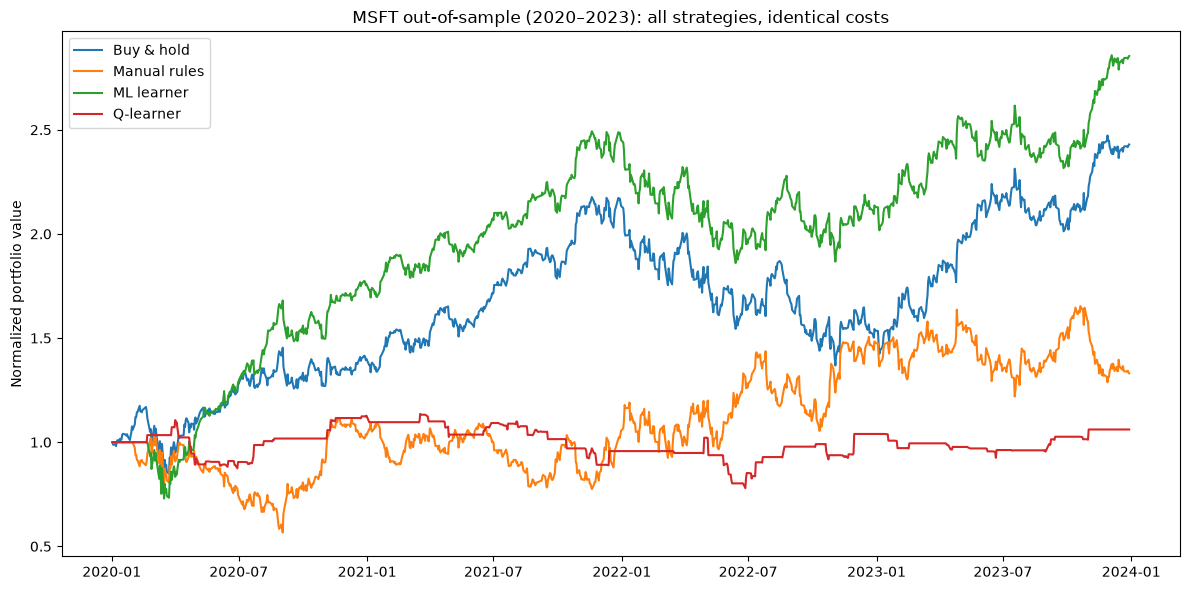

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))
for name, values in curves.items():
    ax.plot(values / values.iloc[0], label=name)
ax.set_title(f"{SYMBOL} out-of-sample (2020–2023): all strategies, identical costs")
ax.set_ylabel("Normalized portfolio value")
ax.legend()
plt.tight_layout()
plt.savefig("../docs/img/09_final_scorecard.png", dpi=120)
plt.show()

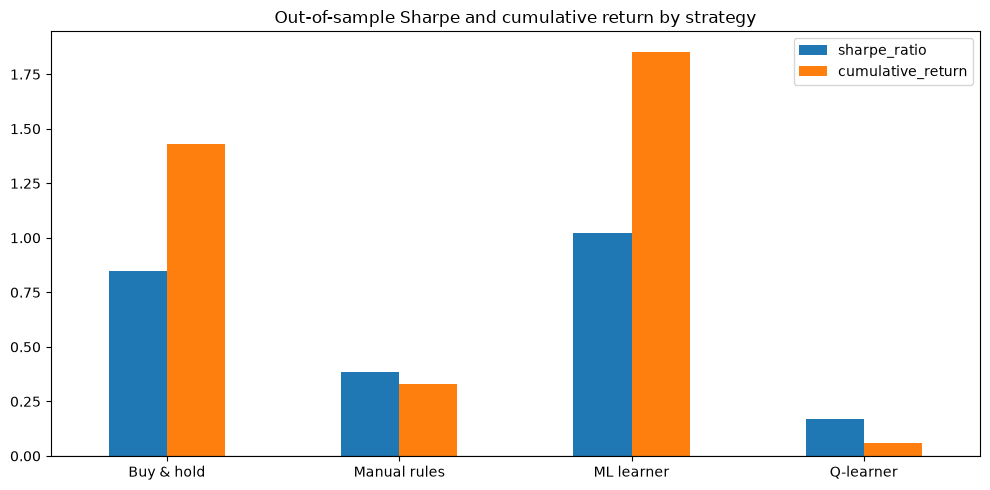

In [4]:
ax = scorecard[["sharpe_ratio", "cumulative_return"]].plot.bar(figsize=(10, 5))
ax.axhline(0, color="black", lw=0.8)
ax.set_xticklabels(scorecard.index, rotation=0)
ax.set_title("Out-of-sample Sharpe and cumulative return by strategy")
plt.tight_layout()
plt.savefig("../docs/img/09_scorecard_bars.png", dpi=120)
plt.show()

## What the full pipeline showed

1. **Hypothesis testing (01):** the Glassdoor outlook factor is statistically
   real (p ≈ 1e-10) but weak (r² ≈ 0.07) — a screening input, not a signal.
2. **Data engineering (02):** one canonical, tested loading path for messy
   scraped fundamentals plus cached market data.
3. **Screening (03):** eight transparent rules compress ~1,170 companies to a
   15-name diligence list; valuation is the binding constraint.
4. **Signal research (04):** mean-reversion indicators carry small but
   consistent information (|IC| < 0.1) — enough to research, not enough to
   print money.
5. **Optimization (05):** max-Sharpe allocation works, but its in-sample edge
   decays out-of-sample; treat optimizers as tilt engines.
6. **Backtesting (06–08):** under identical, cost-aware evaluation, none of
   the active strategies decisively beats buy-and-hold on a strong bull
   ticker out-of-sample. The *infrastructure conclusion* is the durable one:
   in-sample results systematically flatter every method, and only walk-
   forward, cost-aware comparison is trustworthy.

## Limitations

- Single-symbol strategy tests; a cross-sectional (many-stock) portfolio
  strategy is the natural next step and would use the screening universe.
- The fundamentals snapshot is a single 2020 vintage with survivorship bias.
- Transaction cost model is simple (flat commission + linear impact); no
  borrow costs on shorts, no spread modeling.
- No multiple-hypothesis correction across the indicator/strategy grid.

## Future work

- **Cross-sectional ML:** train the tree ensemble on the full screening
  universe with fundamentals + outlook + technicals as features.
- **Deep RL:** replace the Q-table with a DQN to handle continuous state.
- **Fresh alternative data:** re-scrape outlook via an official API and test
  the notebook-01 hypothesis on post-2020 data as true out-of-sample.
- **Execution realism:** spread-aware fills, volume participation limits.

## Theoretically optimal ceiling and full write-up

A lookahead *theoretically optimal strategy* (`quantlab.strategies.theoretically_optimal_trades`) gives an upper bound when costs are zero — useful as a ceiling next to the scorecard above, not as a tradable policy.

The consolidated narrative — stock investment / Glassdoor through strategies, learners, martingale, grid-world RL, and ABIDES — lives in [`docs/RESEARCH_REPORT.md`](../docs/RESEARCH_REPORT.md), with first-implementation results and after-improvements re-runs side by side.
